In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#get data

AVGO_data = yf.download("AVGO", start = "2010-01-01", end = "2026-08-31", interval = "1d", 
                        auto_adjust = False)
AVGO_data.head(5)

#checks
print(f"Increasing: {AVGO_data.index.is_monotonic_increasing}")
print(f"Duplicates: {AVGO_data.index.has_duplicates}")
print(f"Not on Trading days: {(AVGO_data.index.dayofweek > 5).any()}")
print(f"Empty values: {AVGO_data.isna().sum()}")

[*********************100%***********************]  1 of 1 completed

Increasing: True
Duplicates: False
Not on Trading days: False
Empty values: Price      Ticker
Adj Close  AVGO      0
Close      AVGO      0
High       AVGO      0
Low        AVGO      0
Open       AVGO      0
Volume     AVGO      0
dtype: int64


In [3]:
#Calculating Daily returns
AVGO_Daily_Returns = [np.nan]
AVGO_data.head()
prices = AVGO_data["Adj Close"]
prices = prices["AVGO"]

for i in range(1,len(AVGO_data["Adj Close"])):
    r_t = ((prices.iloc[i] / prices.iloc[i-1])-1)*100
    AVGO_Daily_Returns.append(r_t)

print(AVGO_Daily_Returns[0:5])
print(type(AVGO_Daily_Returns[0]))

[nan, np.float64(0.7423435158618652), np.float64(0.7894822943528057), np.float64(-0.6266545994583206), np.float64(0.7356761379149424)]
<class 'float'>


In [4]:
#Maths
print(f"Mean average daily return: {np.nanmean(AVGO_Daily_Returns)}%")
print(f"Standard Deviation: {np.nanstd(AVGO_Daily_Returns, ddof = 1)}")
print(f"Max: {np.nanmax(AVGO_Daily_Returns)}%")
print(f"Min: {np.nanmin(AVGO_Daily_Returns)}%")
total_values = 0
for boolean_statement in np.isnan(AVGO_Daily_Returns):
    if boolean_statement == False:
        total_values+=1
print(f"Total Observations: {total_values}")

Mean average daily return: 0.16360755770906496%
Standard Deviation: 2.4160176620210416
Max: 24.43263156188411%
Min: -19.91290297787337%
Total Observations: 4188


[1, np.float64(1.0074234351586187), np.float64(1.0153768648083568), np.float64(1.0090139589831995), np.float64(1.0164370339076698)]


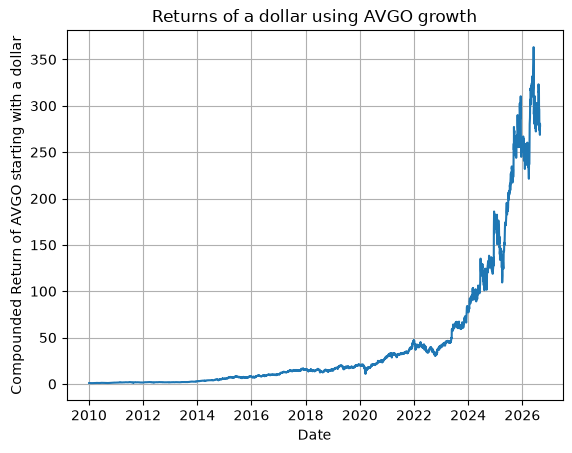

In [8]:
#Cummulative return of $1 using compounded returns of AVGO:
cumulative_return = [1]
for i in range(1, len(AVGO_Daily_Returns)):
    place_holder = cumulative_return[i-1]*(((AVGO_Daily_Returns[i] / 100)) + 1)
    cumulative_return.append(place_holder)

print(cumulative_return[0:5])

#Plot the returns
plt.plot(AVGO_data.index, cumulative_return)
plt.xlabel("Date")
plt.ylabel("Compounded Return of AVGO starting with a dollar")
plt.title("Returns of a dollar using AVGO growth")
plt.grid()

Text(0, 0.5, 'Daily Return')

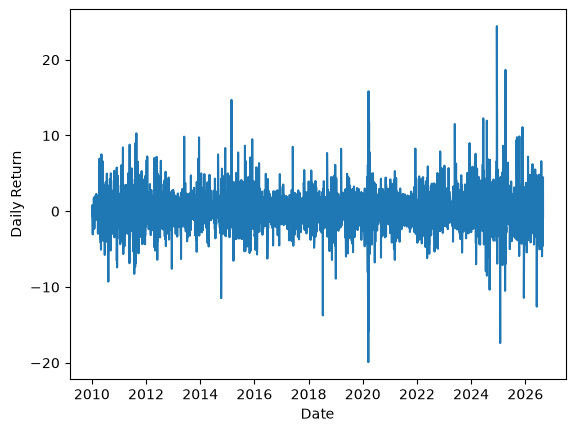

In [6]:
#Plotting it
plt.plot(AVGO_data.index, AVGO_Daily_Returns)
plt.xlabel("Date")
plt.ylabel("Daily Return")